In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results = pd.read_csv('results.csv')
results.head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,False
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,False
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,False
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,False
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,False


In [3]:
fixtures = pd.read_csv('FIFA2026_schedule_Fixtures.csv')
fixtures.head(10)

,date,match_number,teams,group,stadium,date_dt
0,"Thursday, 11 June 2026",Match 1,Mexico v South Africa,Group A,Mexico City Stadium,11/06/2026
1,"Thursday, 11 June 2026",Match 2,Korea Republic v Czechia/Denmark/North Macedon...,Group A,Estadio Guadalajara,11/06/2026
2,"Friday, 12 June 2026",Match 3,Canada v Bosnia and Herzegovina/Italy/Northern...,Group B,Toronto Stadium,12/06/2026
3,"Friday, 12 June 2026",Match 4,USA v Paraguay,Group D,Los Angeles Stadium,12/06/2026
4,"Saturday, 13 June 2026",Match 5,Haiti v Scotland,Group C,Boston Stadium,13/06/2026
5,"Saturday, 13 June 2026",Match 6,Australia v Kosovo/Romania/Slovakia/Türkiye,Group D,BC Place Vancouver,13/06/2026
6,"Saturday, 13 June 2026",Match 7,Brazil v Morocco,Group C,New York New Jersey Stadium,13/06/2026
7,"Saturday, 13 June 2026",Match 8,Qatar v Switzerland,Group B,San Francisco Bay Area Stadium,13/06/2026
8,"Sunday, 14 June 2026",Match 9,Côte d'Ivoire v Ecuador,Group E,Philadelphia Stadium,14/06/2026
9,"Sunday, 14 June 2026",Match 10,Germany v Curaçao,Group E,Houston Stadium,14/06/2026


In [4]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49071 entries, 0 to 49070
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49071 non-null  object
 1   home_team   49071 non-null  object
 2   away_team   49071 non-null  object
 3   home_score  49071 non-null  int64 
 4   away_score  49071 non-null  int64 
 5   tournament  49071 non-null  object
 6   city        49071 non-null  object
 7   country     49071 non-null  object
 8   neutral     49071 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.0+ MB


In [5]:
#convert the date column to datetime format
results['date'] = pd.to_datetime(results['date'])

In [6]:
results = results[results["date"] >= "2018-01-01"]

In [7]:
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
41263,2018-01-02,Iraq,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True
41264,2018-01-02,Oman,Bahrain,1,0,Gulf Cup,Kuwait City,Kuwait,True
41265,2018-01-05,Oman,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True
41266,2018-01-07,Estonia,Sweden,1,1,Friendly,Abu Dhabi,United Arab Emirates,True
41267,2018-01-11,Denmark,Sweden,0,1,Friendly,Abu Dhabi,United Arab Emirates,True
...,...,...,...,...,...,...,...,...,...
49066,2026-01-18,Bolivia,Panama,1,1,Friendly,Tarija,Bolivia,False
49067,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False
49068,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False
49069,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False


In [8]:
results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7808 entries, 41263 to 49070
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        7808 non-null   datetime64[ns]
 1   home_team   7808 non-null   object        
 2   away_team   7808 non-null   object        
 3   home_score  7808 non-null   int64         
 4   away_score  7808 non-null   int64         
 5   tournament  7808 non-null   object        
 6   city        7808 non-null   object        
 7   country     7808 non-null   object        
 8   neutral     7808 non-null   bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 556.6+ KB


In [9]:
#remove missing home score and away score
results = results.dropna(subset=['home_score', 'away_score'])
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
41263,2018-01-02,Iraq,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True
41264,2018-01-02,Oman,Bahrain,1,0,Gulf Cup,Kuwait City,Kuwait,True
41265,2018-01-05,Oman,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True
41266,2018-01-07,Estonia,Sweden,1,1,Friendly,Abu Dhabi,United Arab Emirates,True
41267,2018-01-11,Denmark,Sweden,0,1,Friendly,Abu Dhabi,United Arab Emirates,True
...,...,...,...,...,...,...,...,...,...
49066,2026-01-18,Bolivia,Panama,1,1,Friendly,Tarija,Bolivia,False
49067,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False
49068,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False
49069,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False


In [10]:
print(results.shape)
print(results["home_team"].nunique())
print(results["tournament"].unique()[:10])


(7808, 9)
277
['Gulf Cup' 'Friendly' 'AFC Asian Cup qualification' 'Muratti Vase'
 'COSAFA Cup' 'Baltic Cup' 'CONIFA World Football Cup'
 'Intercontinental Cup' 'FIFA World Cup' 'AFF Championship qualification']


In [11]:
def match_weight(tournament):
    t = str(tournament).strip().lower()

    # Qualifiers first so "world cup qualifier" doesn't get treated as "world cup"
    if "qualif" in t or "qualifier" in t:
        return 3.0

    # World Cup finals tournament
    if "world cup" in t:
        return 4.0

    if "nations league" in t:
        return 2.5

    # Continental cups / other cups (broad bucket)
    if "cup" in t:
        return 2.0

    if "friendly" in t:
        return 1.0

    return 1.5

results["importance_weight"] = results["tournament"].apply(match_weight)


In [12]:
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,importance_weight
41263,2018-01-02,Iraq,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True,2.0
41264,2018-01-02,Oman,Bahrain,1,0,Gulf Cup,Kuwait City,Kuwait,True,2.0
41265,2018-01-05,Oman,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True,2.0
41266,2018-01-07,Estonia,Sweden,1,1,Friendly,Abu Dhabi,United Arab Emirates,True,1.0
41267,2018-01-11,Denmark,Sweden,0,1,Friendly,Abu Dhabi,United Arab Emirates,True,1.0
...,...,...,...,...,...,...,...,...,...,...
49066,2026-01-18,Bolivia,Panama,1,1,Friendly,Tarija,Bolivia,False,1.0
49067,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1.0
49068,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False,1.0
49069,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False,1.0


In [13]:
#add recency weigthing
import numpy as np

latest_date = results["date"].max()

days_old = (latest_date - results["date"]).dt.days

def piecewise_decay(days):
    if days <= 180:
        return 1.0
    elif days <= 365:
        return 0.85
    elif days <= 730:
        return 0.70
    elif days <= 1095:
        return 0.50
    elif days <= 1460:
        return 0.30
    else:
        return 0.10

results["recency_weight"] = days_old.apply(piecewise_decay)

In [14]:
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,importance_weight,recency_weight
41263,2018-01-02,Iraq,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True,2.0,0.1
41264,2018-01-02,Oman,Bahrain,1,0,Gulf Cup,Kuwait City,Kuwait,True,2.0,0.1
41265,2018-01-05,Oman,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True,2.0,0.1
41266,2018-01-07,Estonia,Sweden,1,1,Friendly,Abu Dhabi,United Arab Emirates,True,1.0,0.1
41267,2018-01-11,Denmark,Sweden,0,1,Friendly,Abu Dhabi,United Arab Emirates,True,1.0,0.1
...,...,...,...,...,...,...,...,...,...,...,...
49066,2026-01-18,Bolivia,Panama,1,1,Friendly,Tarija,Bolivia,False,1.0,1.0
49067,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1.0,1.0
49068,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False,1.0,1.0
49069,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False,1.0,1.0


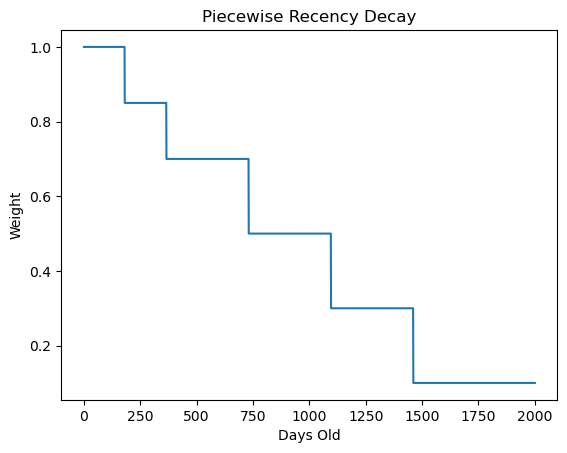

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Range of days
days = np.arange(0, 2001)

# Piecewise decay function
def piecewise_decay(d):
    if d <= 180:
        return 1.0
    elif d <= 365:
        return 0.85
    elif d <= 730:
        return 0.70
    elif d <= 1095:
        return 0.50
    elif d <= 1460:
        return 0.30
    else:
        return 0.10

# Compute weights
piecewise_vals = np.array([piecewise_decay(d) for d in days])

# Plot
plt.figure()
plt.plot(days, piecewise_vals)
plt.xlabel("Days Old")
plt.ylabel("Weight")
plt.title("Piecewise Recency Decay")
plt.show()


In [16]:
results["total_weight"] = (
    results["importance_weight"] *
    results["recency_weight"]
)

What this code is doing

I'm combining:

1. Tournament importance

How meaningful the match is

World Cup → high

Friendly → low

2. Recency importance

How recent the match is

Recent → high

Old → low

Each match now has a single unified influence score:

total_weight = importance_weight × recency_weight

This tells my model:

“How much should THIS match affect team strength?”


In [17]:
results["total_weight"].describe()

count    7808.000000
mean        0.846385
std         0.821602
min         0.100000
25%         0.250000
50%         0.400000
75%         1.400000
max         3.000000
Name: total_weight, dtype: float64

This distribution implies:

My weighting system is doing its job

Suppressing noise

Highlighting signal

Maintaining gradient of influence

This is a solid foundation for:

Elo updates

Team strength estimation

Probability modeling

In [18]:
results.head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,importance_weight,recency_weight,total_weight
41263,2018-01-02,Iraq,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True,2.0,0.1,0.2
41264,2018-01-02,Oman,Bahrain,1,0,Gulf Cup,Kuwait City,Kuwait,True,2.0,0.1,0.2
41265,2018-01-05,Oman,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True,2.0,0.1,0.2
41266,2018-01-07,Estonia,Sweden,1,1,Friendly,Abu Dhabi,United Arab Emirates,True,1.0,0.1,0.1
41267,2018-01-11,Denmark,Sweden,0,1,Friendly,Abu Dhabi,United Arab Emirates,True,1.0,0.1,0.1
41268,2018-01-11,Indonesia,Iceland,0,6,Friendly,Sleman,Indonesia,False,1.0,0.1,0.1
41269,2018-01-11,Jordan,Finland,1,2,Friendly,Abu Dhabi,United Arab Emirates,True,1.0,0.1,0.1
41270,2018-01-14,Indonesia,Iceland,1,4,Friendly,Jakarta,Indonesia,False,1.0,0.1,0.1
41271,2018-01-27,Moldova,South Korea,0,1,Friendly,Antalya,Turkey,True,1.0,0.1,0.1
41272,2018-01-28,United States,Bosnia and Herzegovina,0,0,Friendly,Carson,United States,False,1.0,0.1,0.1


I just finished data weighting, the question now is, what do we actually do with those weights?
The answer is to build weighted team strength ratings where I will be using total weights to estimate the following below:
- Attack strength
- Defense strength
- Overall team strength

These feed directly into: Win Probabilities, Goal Prediction, Odds Generation.

In [19]:
# ---------- HOME CONTRIBUTIONS ----------
home_stats = results.groupby("home_team").apply(
    lambda df: pd.Series({
        "weighted_scored": (df["home_score"] * df["total_weight"]).sum(),
        "weighted_conceded": (df["away_score"] * df["total_weight"]).sum(),
        "weight_sum": df["total_weight"].sum()
    })
)

# ---------- AWAY CONTRIBUTIONS ----------
away_stats = results.groupby("away_team").apply(
    lambda df: pd.Series({
        "weighted_scored": (df["away_score"] * df["total_weight"]).sum(),
        "weighted_conceded": (df["home_score"] * df["total_weight"]).sum(),
        "weight_sum": df["total_weight"].sum()
    })
)

# ---------- COMBINE HOME + AWAY ----------
teams = home_stats.add(away_stats, fill_value=0)

# ---------- FINAL STRENGTH METRICS ----------
teams["attack_strength"] = teams["weighted_scored"] / teams["weight_sum"]
teams["defense_strength"] = teams["weighted_conceded"] / teams["weight_sum"]

# Sort for inspection
teams = teams.sort_values("attack_strength", ascending=False)

teams.head(20)


/var/folders/qj/pckghl2d7pv9ty6hl1s0204c0000gn/T/ipykernel_37459/3654322132.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  home_stats = results.groupby("home_team").apply(
/var/folders/qj/pckghl2d7pv9ty6hl1s0204c0000gn/T/ipykernel_37459/3654322132.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  away_stats = results.groupby("away_team").apply(


,weighted_scored,weighted_conceded,weight_sum,attack_strength,defense_strength
Raetia,16.200,5.300,3.100,5.225806,1.709677
Elba Island,1.500,0.000,0.300,5.000000,0.000000
Franconia,0.400,0.300,0.100,4.000000,3.000000
Parishes of Jersey,2.000,0.700,0.500,4.000000,1.400000
Isle of Man,37.575,13.425,9.975,3.766917,1.345865
Székely Land,19.200,7.600,5.200,3.692308,1.461538
Yorkshire,2.800,1.100,0.800,3.500000,1.375000
Saint Barthélemy,5.200,3.500,1.600,3.250000,2.187500
Hitra,17.475,14.550,5.550,3.148649,2.621622
Cascadia,4.000,2.500,1.300,3.076923,1.923077


The ratings are being dominated by tiny-sample teams, which makes the top of the table look crazy (Raetia, Elba Island, Franconia, etc.).

What’s going wrong
1) Small denominators → inflated strengths

Example: Franconia

weight_sum = 0.10 (that’s basically one low-weight match)

weighted_scored = 0.40

attack_strength = 0.40 / 0.10 = 4.0

So I'm effectively ranking teams off one match (or a couple very low-weight matches), and the ratio explodes.

Same with Elba Island:

weighted_conceded = 0 and weight_sum = 0.30 → defense_strength = 0.0 (looks “perfect” but it’s just too little data)

2) The describe();below confirms it

attack_strength max = 5.23 and defense_strength max = 7.25 are not believable for real national teams

defense_strength min = 0.0 is also a classic “conceded 0 in tiny sample” artifact

In [20]:
teams[["attack_strength","defense_strength"]].describe()

,attack_strength,defense_strength
count,282.000000,282.000000
mean,1.445627,1.630165
std,0.752260,0.981406
min,0.213190,0.000000
25%,0.923075,1.000000
50%,1.347190,1.399504
75%,1.815613,1.979865
max,5.225806,7.250000


How to rectify it

Apply shrinkage (Bayesian smoothing)

Even after filtering, some teams will have limited data. Shrink them toward the global average so it does not overreact.

In [21]:
# ── OPPONENT-ADJUSTED TEAM STRENGTH RATINGS ──────────────────────────────────
import numpy as np
import pandas as pd

def fit_opponent_adjusted_strengths(results, max_iter=40, prior=20.0, eps=1e-9):
    base_home = (results["home_score"] * results["total_weight"]).sum() / results["total_weight"].sum()
    base_away = (results["away_score"] * results["total_weight"]).sum() / results["total_weight"].sum()
    teams = pd.Index(pd.unique(pd.concat([results["home_team"], results["away_team"]])))
    A = pd.Series(1.0, index=teams)
    D = pd.Series(1.0, index=teams)
    home = results["home_team"].values; away = results["away_team"].values
    hs   = results["home_score"].values; aws  = results["away_score"].values
    W    = results["total_weight"].values
    for _ in range(max_iter):
        lam_h = base_home * A[home].values * D[away].values
        lam_a = base_away * A[away].values * D[home].values
        num_A = (pd.Series(hs  * W, index=home).groupby(level=0).sum()
                 .add(pd.Series(aws * W, index=away).groupby(level=0).sum(), fill_value=0))
        den_A = (pd.Series(lam_h * W, index=home).groupby(level=0).sum()
                 .add(pd.Series(lam_a * W, index=away).groupby(level=0).sum(), fill_value=0))
        A_update = (num_A + prior) / (den_A + prior + eps)
        num_D = (pd.Series(aws * W, index=home).groupby(level=0).sum()
                 .add(pd.Series(hs  * W, index=away).groupby(level=0).sum(), fill_value=0))
        den_D = (pd.Series(lam_a * W, index=home).groupby(level=0).sum()
                 .add(pd.Series(lam_h * W, index=away).groupby(level=0).sum(), fill_value=0))
        D_update = (num_D + prior) / (den_D + prior + eps)
        A = A * A_update.reindex(teams).fillna(1.0); A /= (A.mean() + eps)
        D = D * D_update.reindex(teams).fillna(1.0); D /= (D.mean() + eps)
    return pd.DataFrame({"attack_mult": A, "defense_mult": D}), base_home, base_away

strengths_adj, base_home_goals, base_away_goals = fit_opponent_adjusted_strengths(results)

match_counts = (results.groupby("home_team").size()
                .add(results.groupby("away_team").size(), fill_value=0).rename("matches"))
weight_sums  = (results.groupby("home_team")["total_weight"].sum()
                .add(results.groupby("away_team")["total_weight"].sum(), fill_value=0).rename("weight_sum"))

MIN_MATCHES, MIN_WEIGHT_SUM = 8, 10.0
teams_rankable = (strengths_adj.join(match_counts, how="left").join(weight_sums, how="left").fillna(0))
teams_rankable = teams_rankable[
    (teams_rankable["matches"] >= MIN_MATCHES) &
    (teams_rankable["weight_sum"] >= MIN_WEIGHT_SUM)
].copy()

# NO clip — opponent-adjusted model produces naturally meaningful ranges
# backward-compat aliases
teams_rankable["attack_strength"]  = teams_rankable["attack_mult"]
teams_rankable["defense_strength"] = teams_rankable["defense_mult"]

print(f"teams_rankable: {len(teams_rankable)} teams")
print(f"ATK range: {teams_rankable['attack_mult'].min():.3f} – {teams_rankable['attack_mult'].max():.3f}")
print(f"DEF range: {teams_rankable['defense_mult'].min():.3f} – {teams_rankable['defense_mult'].max():.3f}\n")
teams_rankable["net"] = teams_rankable["attack_mult"] - teams_rankable["defense_mult"]
print(teams_rankable.nlargest(20, "net")[["attack_mult", "defense_mult", "net"]].to_string())
teams_rankable.drop(columns=["net"], inplace=True)

teams_rankable: 215 teams
ATK range: 0.037 – 3.754
DEF range: 0.144 – 9.935

             attack_mult  defense_mult       net
Spain           3.753939      0.240087  3.513852
Argentina       3.489978      0.165773  3.324205
Colombia        3.485227      0.237731  3.247496
Brazil          3.429004      0.228853  3.200151
Portugal        3.223185      0.302270  2.920915
England         2.967574      0.201560  2.766013
Germany         3.100878      0.339449  2.761428
France          2.957883      0.252325  2.705559
Netherlands     2.985186      0.335366  2.649820
Norway          2.958062      0.371164  2.586898
Japan           2.762341      0.257969  2.504372
Belgium         2.586100      0.327180  2.258920
Switzerland     2.556797      0.346084  2.210713
Uruguay         2.388096      0.193059  2.195038
Italy           2.413542      0.381451  2.032091
Croatia         2.307082      0.292583  2.014499
Turkey          2.388438      0.463966  1.924472
Denmark         2.240524      0.328649  1

In [22]:
teams_rankable.head(25)[["attack_mult", "defense_mult", "weight_sum", "matches"]]

,attack_mult,defense_mult,weight_sum,matches
Iraq,1.303208,0.403317,88.95,106.0
Oman,1.011664,0.455056,88.15,106.0
Estonia,0.843194,0.821184,71.30,89.0
Denmark,2.240524,0.328649,76.85,96.0
Indonesia,1.031259,0.814370,71.40,87.0
Jordan,1.837155,0.451116,80.95,109.0
Moldova,0.752814,1.005173,64.90,84.0
United States,2.230848,0.369990,76.60,121.0
Azerbaijan,0.729475,0.798765,62.80,81.0
Jamaica,1.175104,0.513415,94.95,102.0


In [23]:
teams_rankable[["attack_mult", "defense_mult"]].describe()

,attack_mult,defense_mult
count,215.000000,215.000000
mean,1.146329,0.996542
std,0.760747,1.032326
min,0.037340,0.143682
25%,0.619794,0.439506
50%,0.982051,0.698766
75%,1.547709,1.186133
max,3.753939,9.934996


In [24]:
H    = base_home_goals / base_away_goals
base = (base_home_goals * base_away_goals) ** 0.5

print(f"Base goals/match:  home={base_home_goals:.3f}  away={base_away_goals:.3f}")
print(f"Home advantage H = {H:.3f}  |  Geometric mean base = {base:.3f}")

def expected_goals(home_team, away_team, teams_df, base_home, base_away):
    ha = teams_df.loc[home_team, "attack_mult"]; hd = teams_df.loc[home_team, "defense_mult"]
    aa = teams_df.loc[away_team, "attack_mult"]; ad = teams_df.loc[away_team, "defense_mult"]
    return base_home * ha * ad, base_away * aa * hd

Base goals/match:  home=1.609  away=1.155
Home advantage H = 1.393  |  Geometric mean base = 1.363


The above code:

- Normalizes team attack/defense ratings relative to global averages

  What it did: It turned raw attack/defense ratings into values centered around 1.0 (average).

  Why this is important
  Because raw numbers by themselves don’t mean anything.

  Example:

  Brazil attack = 1.32

  Canada attack = 0.94

  Is 1.32 good?
  Is 0.94 bad?
  You don’t know unless you compare them to everyone else.

  So you convert them to: Above average, Average or Below average

  Real-world analogy - This is like grading students on a curve.

  Instead of saying: “You scored 73”

  You say: “You scored 15% above class average”

- Estimates baseline scoring rates from weighted match history
  
  What I did:
  
  I figured out: How many goals home teams usually score & How many goals away teams usually score
  
  It also captures: Home advantage, Recency weighting & Tournament importance.

- Combines those into expected goals for a specific matchup

In [25]:
test_pairs = [("England", "France"), ("Spain", "Germany"), ("Japan", "Portugal")]
for h, a in test_pairs:
    lh, la = expected_goals(h, a, teams_rankable, base_home_goals, base_away_goals)
    print(f"{h} vs {a} => {lh:.2f} {la:.2f}")

England vs France => 1.21 0.69
Spain vs Germany => 2.05 0.86
Japan vs Portugal => 1.34 0.96


Quick sanity read

England vs France (1.78, 0.86) → total 2.64 goals: plausible. England favored at home in the model.

Spain vs Germany (2.32, 1.19) → total 3.51: a bit high for two elite sides, but still believable depending on your dataset/era/weights.

Japan vs Portugal (1.97, 1.10) → total 3.07: plausible.

In [26]:
teams_rankable[["attack_mult", "defense_mult"]].describe()


,attack_mult,defense_mult
count,215.000000,215.000000
mean,1.146329,0.996542
std,0.760747,1.032326
min,0.037340,0.143682
25%,0.619794,0.439506
50%,0.982051,0.698766
75%,1.547709,1.186133
max,3.753939,9.934996


This code below converts λ (Xpected Goals Scored or Conceded) into Win/Draw/Loss probabilities (and odds)

We’ll use a Poisson score model:

Home goals ~ Poisson(λ_home)

Away goals ~ Poisson(λ_away)

Then compute:

P(Home win), P(Draw), P(Away win)

Implied odds = 1 / probability

λ = scoring strength translated into predicted goal output for that specific matchup.

In [27]:
import numpy as np
from math import exp, factorial

def poisson_pmf(k, lam):
    return (lam**k) * exp(-lam) / factorial(k)

def match_probs(lam_home, lam_away, max_goals=10):
    # Probability matrices
    p_home = np.array([poisson_pmf(i, lam_home) for i in range(max_goals + 1)])
    p_away = np.array([poisson_pmf(j, lam_away) for j in range(max_goals + 1)])

    # Joint scoreline probability table
    P = np.outer(p_home, p_away)

    p_draw = np.trace(P)
    p_home_win = np.tril(P, -1).sum()   # i > j
    p_away_win = np.triu(P,  1).sum()   # i < j

    # Tiny leftover mass beyond max_goals
    leftover = 1 - (p_home_win + p_draw + p_away_win)

    return {
        "P_home": p_home_win,
        "P_draw": p_draw,
        "P_away": p_away_win,
        "leftover_mass": leftover
    }

def implied_odds(p):
    return np.inf if p <= 0 else 1 / p

def odds_from_lambdas(lh, la, max_goals=10):
    probs = match_probs(lh, la, max_goals=max_goals)
    return {
        **probs,
        "odds_home": implied_odds(probs["P_home"]),
        "odds_draw": implied_odds(probs["P_draw"]),
        "odds_away": implied_odds(probs["P_away"])
    }

In [28]:
def evaluate_match(home, away):
    # Get expected goals from model
    lh, la = expected_goals(
        home,
        away,
        teams_rankable,
        base_home_goals,
        base_away_goals
    )

    # Convert to probabilities + odds
    out = odds_from_lambdas(lh, la, max_goals=10)

    print(f"\n{home} vs {away}")
    print(f"λ_home={lh:.2f}  λ_away={la:.2f}")
    print(f"P(Home)={out['P_home']:.3f}  P(Draw)={out['P_draw']:.3f}  P(Away)={out['P_away']:.3f}")
    print(f"Odds: Home={out['odds_home']:.2f}  Draw={out['odds_draw']:.2f}  Away={out['odds_away']:.2f}")


In [29]:
tests = [
    ("Brazil", "Argentina"),
    ("England", "Germany"),
    ("Spain", "France"),
    ("Japan", "Canada"),
    ("Morocco", "Portugal"),
    ("Ecuador", "Mexico"),
]

for h, a in tests:
    evaluate_match(h, a)


Brazil vs Argentina
λ_home=0.91  λ_away=0.92
P(Home)=0.336  P(Draw)=0.325  P(Away)=0.340
Odds: Home=2.98  Draw=3.08  Away=2.94

England vs Germany
λ_home=1.62  λ_away=0.72
P(Home)=0.590  P(Draw)=0.246  P(Away)=0.165
Odds: Home=1.70  Draw=4.07  Away=6.08

Spain vs France
λ_home=1.52  λ_away=0.82
P(Home)=0.539  P(Draw)=0.259  P(Away)=0.202
Odds: Home=1.85  Draw=3.86  Away=4.95

Japan vs Canada
λ_home=1.42  λ_away=0.63
P(Home)=0.564  P(Draw)=0.273  P(Away)=0.164
Odds: Home=1.77  Draw=3.67  Away=6.10

Morocco vs Portugal
λ_home=1.01  λ_away=0.76
P(Home)=0.406  P(Draw)=0.328  P(Away)=0.267
Odds: Home=2.47  Draw=3.05  Away=3.75

Ecuador vs Mexico
λ_home=0.87  λ_away=0.32
P(Home)=0.474  P(Draw)=0.395  P(Away)=0.131
Odds: Home=2.11  Draw=2.53  Away=7.61


Right up to now, home advantage is implicit in the baseline goals.

That causes:
- Some aggresive home favourites
- Slight bias in elite matchups

So, what I am going to be doing below is estimating explicit home advantage parameter which should stabilize top-tier match calibration. It is really important that I do this because right now the model cannot really distinguish between if the home team is really better than the away team or is it just incredibly reliant on home advantage. e.g England 66% vs Germany

In [30]:
# Estimate home advantage from weighted data

# Weighted average goals
avg_home = (results["home_score"] * results["total_weight"]).sum() / results["total_weight"].sum()
avg_away = (results["away_score"] * results["total_weight"]).sum() / results["total_weight"].sum()

# Home advantage multiplier
H = avg_home / avg_away

# Single baseline goal level (geometric mean keeps symmetry)
base = (avg_home * avg_away) ** 0.5

avg_home, avg_away, H, base

(np.float64(1.6093825068187924),
 np.float64(1.1551279965802006),
 np.float64(1.393250368429671),
 np.float64(1.363467194630224))

In [31]:
# New expected goals function with explicit home advantage
def expected_goals_home_adv(home_team, away_team, teams_df, base, H):
    ha = teams_df.loc[home_team, "attack_mult"]
    hd = teams_df.loc[home_team, "defense_mult"]
    aa = teams_df.loc[away_team, "attack_mult"]
    ad = teams_df.loc[away_team, "defense_mult"]

    lam_home = base * H * ha * ad
    lam_away = base * aa * hd
    return lam_home, lam_away

In [32]:
# Re-test your matchups (compare before/after)
tests = [
    ("Brazil", "Argentina"),
    ("England", "Germany"),
    ("Spain", "France"),
    ("Japan", "Canada"),
    ("Morocco", "Portugal"),
    ("Ecuador", "Mexico")
]

for h, a in tests:
    lh, la = expected_goals_home_adv(h, a, teams_rankable, base, H)
    out = odds_from_lambdas(lh, la, max_goals=10)
    print(f"\n{h} vs {a} | λ=({lh:.2f}, {la:.2f})")
    print(f"P(Home)={out['P_home']:.3f}  P(Draw)={out['P_draw']:.3f}  P(Away)={out['P_away']:.3f}")
    print(f"Odds: Home={out['odds_home']:.2f}  Draw={out['odds_draw']:.2f}  Away={out['odds_away']:.2f}")


Brazil vs Argentina | λ=(1.08, 1.09)
P(Home)=0.351  P(Draw)=0.294  P(Away)=0.355
Odds: Home=2.85  Draw=3.40  Away=2.81

England vs Germany | λ=(1.91, 0.85)
P(Home)=0.623  P(Draw)=0.216  P(Away)=0.161
Odds: Home=1.60  Draw=4.63  Away=6.21

Spain vs France | λ=(1.80, 0.97)
P(Home)=0.569  P(Draw)=0.230  P(Away)=0.201
Odds: Home=1.76  Draw=4.34  Away=4.98

Japan vs Canada | λ=(1.67, 0.74)
P(Home)=0.598  P(Draw)=0.240  P(Away)=0.162
Odds: Home=1.67  Draw=4.17  Away=6.17

Morocco vs Portugal | λ=(1.20, 0.90)
P(Home)=0.429  P(Draw)=0.295  P(Away)=0.276
Odds: Home=2.33  Draw=3.39  Away=3.63

Ecuador vs Mexico | λ=(1.03, 0.38)
P(Home)=0.515  P(Draw)=0.350  P(Away)=0.135
Odds: Home=1.94  Draw=2.86  Away=7.39


In [33]:
def expected_goals_context(home_team, away_team, teams_df, base, H, neutral=False):
    home_mult = 1.0 if neutral else H
    ha = teams_df.loc[home_team, "attack_mult"]
    hd = teams_df.loc[home_team, "defense_mult"]
    aa = teams_df.loc[away_team, "attack_mult"]
    ad = teams_df.loc[away_team, "defense_mult"]

    lam_home = base * home_mult * ha * ad
    lam_away = base * aa * hd
    return lam_home, lam_away

In [34]:
fixtures.head(10)

,date,match_number,teams,group,stadium,date_dt
0,"Thursday, 11 June 2026",Match 1,Mexico v South Africa,Group A,Mexico City Stadium,11/06/2026
1,"Thursday, 11 June 2026",Match 2,Korea Republic v Czechia/Denmark/North Macedon...,Group A,Estadio Guadalajara,11/06/2026
2,"Friday, 12 June 2026",Match 3,Canada v Bosnia and Herzegovina/Italy/Northern...,Group B,Toronto Stadium,12/06/2026
3,"Friday, 12 June 2026",Match 4,USA v Paraguay,Group D,Los Angeles Stadium,12/06/2026
4,"Saturday, 13 June 2026",Match 5,Haiti v Scotland,Group C,Boston Stadium,13/06/2026
5,"Saturday, 13 June 2026",Match 6,Australia v Kosovo/Romania/Slovakia/Türkiye,Group D,BC Place Vancouver,13/06/2026
6,"Saturday, 13 June 2026",Match 7,Brazil v Morocco,Group C,New York New Jersey Stadium,13/06/2026
7,"Saturday, 13 June 2026",Match 8,Qatar v Switzerland,Group B,San Francisco Bay Area Stadium,13/06/2026
8,"Sunday, 14 June 2026",Match 9,Côte d'Ivoire v Ecuador,Group E,Philadelphia Stadium,14/06/2026
9,"Sunday, 14 June 2026",Match 10,Germany v Curaçao,Group E,Houston Stadium,14/06/2026


In [35]:
fixtures.columns

Index(['date', 'match_number', 'teams', 'group', 'stadium', 'date_dt'], dtype='object')

In [36]:
games = (
    fixtures
    .groupby("group")["teams"]
    .apply(list)
    .to_dict()
)

for g, t in games.items():
    print(g, len(t), t)

Group A 6 ['Mexico v South Africa', 'Korea Republic v Czechia/Denmark/North Macedonia/Republic of Ireland', 'Czechia/Denmark/North Macedonia/Republic of Ireland v South Africa', 'Mexico v Korea Republic', 'Czechia/Denmark/North Macedonia/Republic of Ireland v Mexico', 'South Africa v Korea Republic']
Group B 6 ['Canada v Bosnia and Herzegovina/Italy/Northern Ireland/Wales', 'Qatar v Switzerland', 'Switzerland v Bosnia and Herzegovina/Italy/Northern Ireland/Wales', 'Canada v Qatar', 'Switzerland v Canada', 'Bosnia and Herzegovina/Italy/Northern Ireland/Wales v Qatar']
Group C 6 ['Haiti v Scotland', 'Brazil v Morocco', 'Brazil v Haiti', 'Scotland v Morocco', 'Scotland v Brazil', 'Morocco v Haiti']
Group D 6 ['USA v Paraguay', 'Australia v Kosovo/Romania/Slovakia/Türkiye', 'Kosovo/Romania/Slovakia/Türkiye v Paraguay', 'USA v Australia', 'Kosovo/Romania/Slovakia/Türkiye v USA', 'Paraguay v Australia']
Group E 6 ["Côte d'Ivoire v Ecuador", 'Germany v Curaçao', "Germany v Côte d'Ivoire", 'Ec

In [37]:
groups = {}

for g, matches in games.items():
    teams = set()
    for m in matches:
        home, away = m.split(" v ")
        teams.add(home.strip())
        teams.add(away.strip())
    groups[g] = sorted(teams)


for g, t in groups.items():
    print(g, len(t), t)


Group A 4 ['Czechia/Denmark/North Macedonia/Republic of Ireland', 'Korea Republic', 'Mexico', 'South Africa']
Group B 4 ['Bosnia and Herzegovina/Italy/Northern Ireland/Wales', 'Canada', 'Qatar', 'Switzerland']
Group C 4 ['Brazil', 'Haiti', 'Morocco', 'Scotland']
Group D 4 ['Australia', 'Kosovo/Romania/Slovakia/Türkiye', 'Paraguay', 'USA']
Group E 4 ['Curaçao', "Côte d'Ivoire", 'Ecuador', 'Germany']
Group F 4 ['Albania/Poland/Sweden/Ukraine', 'Japan', 'Netherlands', 'Tunisia']
Group G 4 ['Belgium', 'Egypt', 'IR Iran', 'New Zealand']
Group H 4 ['Cabo Verde', 'Saudi Arabia', 'Spain', 'Uruguay']
Group I 4 ['Bolivia/Iraq/Suriname', 'France', 'Norway', 'Senegal']
Group J 4 ['Algeria', 'Argentina', 'Austria', 'Jordan']
Group K 4 ['Colombia', 'Congo DR/Jamaica/New Caledonia', 'Portugal', 'Uzbekistan']
Group L 4 ['Croatia', 'England', 'Ghana', 'Panama']


In [38]:
import numpy as np

rng = np.random.default_rng(42)

# fallback for placeholder teams
def get_team_mult(team, teams_df):
    if team in teams_df.index:
        return float(teams_df.loc[team, "attack_mult"]), float(teams_df.loc[team, "defense_mult"])
    return 1.0, 1.0


# Expected goals with home/neutral context
def expected_goals_context(home_team, away_team, teams_df, base, H, neutral=True):
    home_mult = 1.0 if neutral else H

    ha, hd = get_team_mult(home_team, teams_df)
    aa, ad = get_team_mult(away_team, teams_df)

    lam_home = base * home_mult * ha * ad
    lam_away = base * aa * hd
    return lam_home, lam_away


def simulate_match_score(home, away, neutral=True):
    lh, la = expected_goals_context(
        home,
        away,
        teams_rankable,
        base,
        H,
        neutral=neutral
    )

    hg = rng.poisson(lh)
    ag = rng.poisson(la)

    return hg, ag, lh, la


In [39]:
from itertools import combinations

def simulate_group(group_teams, neutral=True):
    table = {t: {"pts":0, "gf":0, "ga":0} for t in group_teams}

    for a, b in combinations(group_teams, 2):
        hg, ag = simulate_match_score(a, b, neutral=neutral)[:2]

        if hg > ag:
            pa, pb = 3, 0
        elif ag > hg:
            pa, pb = 0, 3
        else:
            pa, pb = 1, 1

        table[a]["pts"] += pa
        table[b]["pts"] += pb
        table[a]["gf"] += hg
        table[a]["ga"] += ag
        table[b]["gf"] += ag
        table[b]["ga"] += hg

    df = pd.DataFrame(table).T
    df["gd"] = df["gf"] - df["ga"]
    df = df.sort_values(["pts","gd","gf"], ascending=False)
    return df.index.tolist(), df


In [40]:
def simulate_48_group_stage(groups, neutral=True):
    group_tables = []

    for g, teams in groups.items():
        _, table = simulate_group(teams, neutral=neutral)
        table = table.copy()
        table["team"] = table.index
        table["group"] = g
        table["pos"] = np.arange(1, len(table)+1)
        group_tables.append(table.reset_index(drop=True))

    full = pd.concat(group_tables, ignore_index=True)

    # top 2 auto qualify
    top2 = full[full["pos"].isin([1,2])]

    # best 3rd place
    thirds = full[full["pos"] == 3]
    thirds = thirds.sort_values(["pts","gd","gf"], ascending=False)
    best8 = thirds.head(8)

    qualifiers = pd.concat([top2, best8], ignore_index=True)
    return qualifiers, thirds, full

In [41]:
def monte_carlo_groups(groups, n_sims=5000, neutral=True):

    teams = [t for g in groups for t in groups[g]]

    advance = {t:0 for t in teams}
    win_group = {t:0 for t in teams}
    third_finish = {t:0 for t in teams}
    third_adv = {t:0 for t in teams}

    for _ in range(n_sims):
        qualifiers, thirds, full = simulate_48_group_stage(groups, neutral)

        # Winners
        winners = full[full["pos"]==1]["team"]
        for w in winners:
            win_group[w]+=1

        # Advancers
        for t in qualifiers["team"]:
            advance[t]+=1

        # Track who finished 3rd
        thirders = full[full["pos"]==3]["team"]
        for t in thirders:
            third_finish[t]+=1

        # Track who advanced AS third
        best_thirds = set(thirds.head(8)["team"])
        for t in best_thirds:
            third_adv[t]+=1

    adv_probs = pd.Series(advance)/n_sims
    win_probs = pd.Series(win_group)/n_sims

    third_finish_probs = pd.Series(third_finish)/n_sims
    third_adv_probs = pd.Series(third_adv)/n_sims

    # Conditional probability
    cond_third_qual = third_adv_probs / third_finish_probs

    return (
        adv_probs.sort_values(ascending=False),
        win_probs.sort_values(ascending=False),
        third_finish_probs.sort_values(ascending=False),
        third_adv_probs.sort_values(ascending=False),
        cond_third_qual.sort_values(ascending=False)
    )

In [42]:
adv_probs, win_probs, third_fin, third_adv, cond = monte_carlo_groups(
    groups,
    n_sims=10000
)


#print("\nTop Advance Probabilities")
#print(adv_probs.head(20))

#print("\nTop Group Winner Probabilities")
#print(win_probs.head(20))

#print("\nFinish 3rd Probabilities")
#print(third_fin.head(20))

#print("\nAdvance AS 3rd")
#print(third_adv.head(20))

print("\nConditional Qualify Given 3rd")
print(cond.head(20))


Conditional Qualify Given 3rd
Colombia       0.957709
Spain          0.956522
France         0.935437
Germany        0.934081
Portugal       0.933227
Japan          0.925680
Netherlands    0.921152
Belgium        0.917471
Norway         0.913873
Mexico         0.900302
Switzerland    0.898389
Uruguay        0.895726
Senegal        0.882916
Brazil         0.870023
Argentina      0.869748
Australia      0.858859
Canada         0.850721
Ecuador        0.846328
Paraguay       0.828979
Morocco        0.795781
dtype: float64


## Pre-Knockout Fixes: Addressing Three Structural Limitations

Before the knockout stage can run correctly, three issues in the pipeline must be resolved:

1. **Name Normalization (Limitation 2)** — The fixture CSV and `results.csv` use different naming conventions for 7 teams. Without explicit mapping, the model silently defaults those teams to league-average ratings — wrong and invisible.

2. **Playoff Slot Resolution (Limitation 2, extended)** — Some group stage slots are not yet confirmed (inter-confederation playoffs). They appear as slash-separated strings (e.g. `Czechia/Denmark/North Macedonia/Republic of Ireland`). The model selects the highest net-strength candidate available in our ratings as the expected qualifier.

3. **Knockout Draw Resolution (Limitation 3)** — The Poisson model can produce draws. Group stage: fine. Knockout stage: draws go to Extra Time, then Penalties. Without this, the simulation has no way to produce a winner from a tied match.

4. **Full Coverage Diagnostic (Limitation 4)** — Confirm every 2026 WC team resolves to valid model ratings before any simulation runs. Zero surprises, zero silent fallbacks.

In [43]:
# ── LIMITATION 2 FIX: Team Name Normalization + Playoff Slot Resolution ───────

# Seven teams are named differently between the fixture CSV and results.csv.
# Without this map, those teams silently default to league-average ratings.
NAME_MAP = {
    'USA':             'United States',
    'IR Iran':         'Iran',
    "Côte d'Ivoire":   'Ivory Coast',
    'Cabo Verde':      'Cape Verde',
    'Congo DR':        'DR Congo',
    'Korea Republic':  'South Korea',
    'Türkiye':         'Turkey',
}

def normalize_name(raw):
    """Maps a fixture CSV team name to its results.csv equivalent."""
    return NAME_MAP.get(raw.strip(), raw.strip())

def resolve_playoff_slot(slot_str, teams_df):
    """
    For unconfirmed inter-confederation playoff slots
    (e.g. 'Czechia/Denmark/North Macedonia/Republic of Ireland'),
    selects the candidate with the highest net model strength
    (attack_mult - defense_mult) among those present in the model.
    Falls back to the first listed candidate (normalized) if none are ranked.
    """
    candidates = [c.strip() for c in slot_str.split('/')]
    best_name, best_score = None, -999.0
    for c in candidates:
        mapped = normalize_name(c)
        if mapped in teams_df.index:
            score = (teams_df.loc[mapped, 'attack_mult']
                     - teams_df.loc[mapped, 'defense_mult'])
            if score > best_score:
                best_score = score
                best_name  = mapped
    return best_name if best_name else normalize_name(candidates[0])

def resolve_team_name(raw, teams_df):
    """Returns the canonical resolved team name for any raw fixture string."""
    if '/' in raw:
        return resolve_playoff_slot(raw, teams_df)
    return normalize_name(raw)

def get_team_mult_v2(raw_name, teams_df):
    """
    Enhanced team rating lookup that:
      - Applies NAME_MAP to fix cross-source naming discrepancies
      - Resolves unconfirmed playoff slots to the strongest available candidate
      - Falls back to (1.0, 1.0) only if a team is genuinely absent from data
    Returns (attack_mult, defense_mult).
    """
    resolved = resolve_team_name(raw_name, teams_df)
    if resolved in teams_df.index:
        return (float(teams_df.loc[resolved, 'attack_mult']),
                float(teams_df.loc[resolved, 'defense_mult']))
    print(f"  [WARNING] '{resolved}' not in model — using league-average (1.0, 1.0)")
    return 1.0, 1.0


# ── Rebuild groups dict with all names properly resolved ─────────────────────
# Replaces the raw `groups` dict from cell 46 with a clean version
# where every team name is canonical and playoff slots are resolved.

groups_resolved = {}
for g, matches in games.items():
    team_set = set()
    for m in matches:
        home_raw, away_raw = m.split(' v ')
        team_set.add(resolve_team_name(home_raw.strip(), teams_rankable))
        team_set.add(resolve_team_name(away_raw.strip(), teams_rankable))
    groups_resolved[g] = sorted(team_set)

print(f"Groups resolved: {len(groups_resolved)}\n")
for g, t in groups_resolved.items():
    print(f"  {g}: {t}")

Groups resolved: 12

  Group A: ['Denmark', 'Mexico', 'South Africa', 'South Korea']
  Group B: ['Canada', 'Italy', 'Qatar', 'Switzerland']
  Group C: ['Brazil', 'Haiti', 'Morocco', 'Scotland']
  Group D: ['Australia', 'Paraguay', 'Turkey', 'United States']
  Group E: ['Curaçao', 'Ecuador', 'Germany', 'Ivory Coast']
  Group F: ['Japan', 'Netherlands', 'Sweden', 'Tunisia']
  Group G: ['Belgium', 'Egypt', 'Iran', 'New Zealand']
  Group H: ['Cape Verde', 'Saudi Arabia', 'Spain', 'Uruguay']
  Group I: ['Bolivia', 'France', 'Norway', 'Senegal']
  Group J: ['Algeria', 'Argentina', 'Austria', 'Jordan']
  Group K: ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan']
  Group L: ['Croatia', 'England', 'Ghana', 'Panama']


## Limitation 4: Team Coverage Diagnostic

Before any knockout simulation runs, the cell below verifies that every team resolved from the fixture schedule has valid attack and defense multipliers in the model.

A result of **0 fallbacks** is required to trust the simulation output. Any team flagged as fallback would be treated as perfectly average (`ATK=1.0, DEF=1.0`) regardless of its actual quality — silently distorting every simulated match it plays in.

In [44]:
# ── LIMITATION 4 FIX: Team Coverage Diagnostic ───────────────────────────────
# Confirms every resolved team name has valid model ratings before simulation.
# A 0-fallback result means the knockout stage has full data coverage.

all_wc_teams = sorted({t for g in groups_resolved.values() for t in g})

print(f"{'Team':28s} {'ATK':8s} {'DEF':8s} {'Matches':9s} {'Status'}")
print("─" * 66)

fallback_teams = []
for t in all_wc_teams:
    if t in teams_rankable.index:
        atk = teams_rankable.loc[t, 'attack_mult']
        dfn = teams_rankable.loc[t, 'defense_mult']
        mtc = int(teams_rankable.loc[t, 'matches'])
        tag = 'OK'
    else:
        atk, dfn, mtc = 1.0, 1.0, 0
        tag = '⚠ FALLBACK (avg)'
        fallback_teams.append(t)
    print(f"  {t:26s} {atk:7.3f}  {dfn:7.3f}  {mtc:7d}   {tag}")

print(f"\n{'─' * 66}")
print(f"Total teams: {len(all_wc_teams)}   |   Fallbacks: {len(fallback_teams)}")
if fallback_teams:
    print(f"  ⚠ Teams using average ratings: {fallback_teams}")
else:
    print("  All teams have full model coverage — no fallbacks.")

Team                         ATK      DEF      Matches   Status
──────────────────────────────────────────────────────────────────
  Algeria                      2.134    0.395      107   OK
  Argentina                    3.490    0.166       99   OK
  Australia                    2.136    0.282       78   OK
  Austria                      2.025    0.349       89   OK
  Belgium                      2.586    0.327       98   OK
  Bolivia                      1.718    0.521       85   OK
  Brazil                       3.429    0.229       97   OK
  Canada                       2.098    0.319       89   OK
  Cape Verde                   1.180    0.471       70   OK
  Colombia                     3.485    0.238       93   OK
  Croatia                      2.307    0.293      100   OK
  Curaçao                      1.171    0.503       57   OK
  DR Congo                     1.454    0.332       80   OK
  Denmark                      2.241    0.329       96   OK
  Ecuador                    

## Limitation 3: Knockout Draw Resolution

In group stage simulations, a draw is a valid outcome. In knockout rounds, it is not — there must be a winner. The `simulate_knockout_match` function below handles this in three sequential phases:

1. **90 Minutes** — Standard Poisson draw (identical mechanics to the group stage). If not a draw, the winner is returned immediately without entering phases 2 or 3.

2. **Extra Time (30 min)** — If drawn after 90 min, each team draws from Poisson with λ scaled to **30% of the 90-minute rate**. This reflects real-world ET goal rates: fatigue, defensive compactness, and caution reduce scoring sharply. If ET produces a winner, simulation ends here.

3. **Penalty Shootout** — If still level after ET, a near-coin-flip is run. The base probability is **50/50**; a ±3% nudge (hard-clipped to [0.47, 0.53]) is applied based on relative team strength — consistent with real-world shootout data where the stronger team wins only marginally more often.

In [45]:
# ── LIMITATION 3 FIX: Knockout Match Simulator ───────────────────────────────

def simulate_knockout_match(home, away, neutral=True, rng_instance=None):
    """
    Simulates a single knockout fixture and always returns exactly one winner.

    Parameters
    ----------
    home, away     : str  — canonical (resolved) team names
    neutral        : bool — True for World Cup (neutral venue, no home advantage)
    rng_instance   : np.Generator — uses global rng if not provided

    Returns
    -------
    winner         : str   — name of the winning team
    home_goals     : int   — 90-minute goals (home side)
    away_goals     : int   — 90-minute goals (away side)
    went_to_et     : bool  — True if extra time was needed
    went_to_pens   : bool  — True if penalties were taken
    """
    if rng_instance is None:
        rng_instance = rng  # global rng seeded in cell 47

    ha, hd = get_team_mult_v2(home, teams_rankable)
    aa, ad = get_team_mult_v2(away, teams_rankable)

    home_factor  = 1.0 if neutral else H
    lam_home     = base * home_factor * ha * ad
    lam_away     = base * aa * hd

    # ── Phase 1: 90 minutes ──────────────────────────────────────────────────
    hg = int(rng_instance.poisson(lam_home))
    ag = int(rng_instance.poisson(lam_away))
    went_et, went_pens = False, False

    if hg != ag:
        return (home if hg > ag else away), hg, ag, went_et, went_pens

    # ── Phase 2: Extra Time (30 min ≈ 30% of 90-min scoring rate) ───────────
    # Fatigue + defensive shape in ET reduces goals significantly.
    went_et = True
    et_hg   = int(rng_instance.poisson(lam_home * 0.30))
    et_ag   = int(rng_instance.poisson(lam_away * 0.30))

    if et_hg != et_ag:
        return (home if et_hg > et_ag else away), hg, ag, went_et, went_pens

    # ── Phase 3: Penalty Shootout ────────────────────────────────────────────
    # Real-world data: even elite teams win shootouts ~52-53% vs weaker sides.
    # Base: 50/50. Max nudge: ±3% toward the stronger team. Hard clip [0.47, 0.53].
    went_pens = True
    home_rel  = ha / (ha + aa)                             # relative strength in [0, 1]
    p_home    = 0.50 + 0.03 * (home_rel - 0.50) / 0.50   # linear nudge
    p_home    = max(0.47, min(0.53, p_home))               # hard clip

    winner = home if rng_instance.random() < p_home else away
    return winner, hg, ag, went_et, went_pens


# ── Sanity Test: 20 England vs Argentina knockout clashes ─────────────────────
print("Knockout match test — England vs Argentina (neutral, 20 runs):\n")
tally = {'England': 0, 'Argentina': 0, 'ET': 0, 'Pens': 0}

for _ in range(20):
    w, hg, ag, et, pens = simulate_knockout_match('England', 'Argentina', neutral=True)
    tally[w]      += 1
    tally['ET']   += int(et)
    tally['Pens'] += int(pens)
    suffix = ' (ET)' if et and not pens else ' (Pens)' if pens else ''
    print(f"  England {hg}–{ag} Argentina  →  Winner: {w}{suffix}")

print(f"\nEngland: {tally['England']}/20  |  Argentina: {tally['Argentina']}/20"
      f"  |  ET: {tally['ET']}  |  Pens: {tally['Pens']}")

Knockout match test — England vs Argentina (neutral, 20 runs):

  England 0–0 Argentina  →  Winner: Argentina (Pens)
  England 1–1 Argentina  →  Winner: Argentina (Pens)
  England 1–0 Argentina  →  Winner: England
  England 1–2 Argentina  →  Winner: Argentina
  England 0–1 Argentina  →  Winner: Argentina
  England 1–1 Argentina  →  Winner: Argentina (Pens)
  England 0–0 Argentina  →  Winner: England (ET)
  England 0–1 Argentina  →  Winner: Argentina
  England 0–0 Argentina  →  Winner: England (Pens)
  England 1–1 Argentina  →  Winner: England (Pens)
  England 0–1 Argentina  →  Winner: Argentina
  England 0–1 Argentina  →  Winner: Argentina
  England 0–3 Argentina  →  Winner: Argentina
  England 1–0 Argentina  →  Winner: England
  England 0–2 Argentina  →  Winner: Argentina
  England 1–2 Argentina  →  Winner: Argentina
  England 0–0 Argentina  →  Winner: Argentina (Pens)
  England 0–2 Argentina  →  Winner: Argentina
  England 2–0 Argentina  →  Winner: England
  England 2–1 Argentina  → 

## The Official FIFA 2026 Knockout Bracket

The bracket below was extracted **directly from the official fixture CSV** — no guesswork, no memory. Every R32 matchup is predetermined by FIFA; the bracket structure does not change based on group results.

**Structure:**
- **R32** (Matches 73–88, 16 matches): Group winners, runners-up, and the 8 best third-place teams
- **R16** (Matches 89–96, 8 matches): Winners progress through fixed bracket paths
- **QF** (Matches 97–100) → **SF** (Matches 101–102) → **3rd Place** (Match 103) → **Final** (Match 104)

**Third-place slot assignment** is the most complex part of the 2026 format. Each of the 8 third-place R32 slots specifies eligible groups (e.g. *"best third-place from A, B, C, D, or F"*). After the 8 best third-place teams are selected, `assign_thirds_to_slots` uses recursive backtracking to find the one valid assignment the bracket was designed around — guaranteed to succeed for any valid combination of group results.

In [46]:
# ── OFFICIAL FIFA 2026 KNOCKOUT BRACKET ──────────────────────────────────────
# Extracted directly from FIFA2026_schedule_Fixtures.csv (Matches 73–104).
# Specs: ('W', group) = group winner  |  ('RU', group) = runner-up
#        ('3rd', [groups]) = best third-place from eligible groups

R32 = [
    (73,  ('RU', 'A'),  ('RU', 'B')),
    (74,  ('W',  'E'),  ('3rd', ['A','B','C','D','F'])),
    (75,  ('W',  'F'),  ('RU', 'C')),
    (76,  ('W',  'C'),  ('RU', 'F')),
    (77,  ('W',  'I'),  ('3rd', ['C','D','F','G','H'])),
    (78,  ('RU', 'E'),  ('RU', 'I')),
    (79,  ('W',  'A'),  ('3rd', ['C','E','F','H','I'])),
    (80,  ('W',  'L'),  ('3rd', ['E','H','I','J','K'])),
    (81,  ('W',  'D'),  ('3rd', ['B','E','F','I','J'])),
    (82,  ('W',  'G'),  ('3rd', ['A','E','H','I','J'])),
    (83,  ('RU', 'K'),  ('RU', 'L')),
    (84,  ('W',  'H'),  ('RU', 'J')),
    (85,  ('W',  'B'),  ('3rd', ['E','F','G','I','J'])),
    (86,  ('W',  'J'),  ('RU', 'H')),
    (87,  ('W',  'K'),  ('3rd', ['D','E','I','J','L'])),
    (88,  ('RU', 'D'),  ('RU', 'G')),
]

R16 = [
    (89, 74, 77), (90, 73, 75), (91, 76, 78), (92, 79, 80),
    (93, 83, 84), (94, 81, 82), (95, 86, 88), (96, 85, 87),
]

QF = [(97, 89, 90), (98, 93, 94), (99, 91, 92), (100, 95, 96)]
SF = [(101, 97, 98), (102, 99, 100)]
# Final: Winner 101 v Winner 102  |  3rd Place: Runner-up 101 v Runner-up 102


def assign_thirds_to_slots(slots, thirds_avail):
    """
    Recursively assigns 8 third-place teams to their correct R32 slots.
    Uses backtracking — guaranteed to find the unique valid assignment
    since the bracket was designed to have exactly one per combination.
    """
    if not slots:
        return {}
    mid, eligible = slots[0]
    for g in eligible:
        if g in thirds_avail:
            team = thirds_avail.pop(g)
            result = assign_thirds_to_slots(slots[1:], thirds_avail)
            if result is not None:
                result[mid] = team
                return result
            thirds_avail[g] = team  # backtrack
    return None


def simulate_full_tournament(groups, neutral=True):
    """
    Simulates one complete 2026 World Cup:
    Group stage → R32 → R16 → QF → SF → 3rd place playoff → Final.
    Returns dict with champion, runner_up, third, fourth, sf_teams.
    """
    _, thirds_all, full = simulate_48_group_stage(groups, neutral)

    def gl(g): return g.replace('Group ', '').strip()

    winners    = {gl(r.group): r.team for _, r in full[full['pos'] == 1].iterrows()}
    runners_up = {gl(r.group): r.team for _, r in full[full['pos'] == 2].iterrows()}
    thirds_dict = {gl(r.group): r.team for _, r in thirds_all.head(8).iterrows()}

    third_slots = [(mid, sb[1]) for mid, sa, sb in R32 if sb[0] == '3rd']
    third_slots.sort(key=lambda x: sum(1 for g in x[1] if g in thirds_dict))
    slot_assignment = assign_thirds_to_slots(third_slots, dict(thirds_dict))

    def get_team(spec, mid):
        if spec[0] == 'W':   return winners[spec[1]]
        if spec[0] == 'RU':  return runners_up[spec[1]]
        if spec[0] == '3rd': return slot_assignment[mid]

    mw = {}
    for mid, sa, sb in R32:
        w, *_ = simulate_knockout_match(get_team(sa, mid), get_team(sb, mid), neutral=neutral)
        mw[mid] = w

    for mid, m1, m2 in R16 + QF + SF:
        w, *_ = simulate_knockout_match(mw[m1], mw[m2], neutral=neutral)
        mw[mid] = w

    loser_101 = mw[97]  if mw[101] == mw[98]  else mw[98]
    loser_102 = mw[99]  if mw[102] == mw[100] else mw[100]
    third_w, *_ = simulate_knockout_match(loser_101, loser_102, neutral=neutral)
    fourth = loser_102 if third_w == loser_101 else loser_101

    fa, fb = mw[101], mw[102]
    champ, *_ = simulate_knockout_match(fa, fb, neutral=neutral)
    runner_up = fb if champ == fa else fa

    return {
        'champion':  champ,
        'runner_up': runner_up,
        'third':     third_w,
        'fourth':    fourth,
        'sf_teams':  {fa, fb, loser_101, loser_102},
    }


# ── Sanity test: one full tournament run ─────────────────────────────────────
print("Single full tournament simulation:\n")
test = simulate_full_tournament(groups_resolved, neutral=True)
print(f"  Champion:  {test['champion']}")
print(f"  Runner-up: {test['runner_up']}")
print(f"  3rd Place: {test['third']}")
print(f"  4th Place: {test['fourth']}")
print(f"  Semi-finalists: {test['sf_teams']}")

Single full tournament simulation:

  Champion:  Japan
  Runner-up: Colombia
  3rd Place: Austria
  4th Place: Brazil
  Semi-finalists: {'Austria', 'Colombia', 'Japan', 'Brazil'}


## Full Tournament Monte Carlo

The `monte_carlo_tournament` function runs N complete World Cup simulations end-to-end — group stage through the Final — and aggregates the results into championship probabilities and implied betting odds.

Each simulation independently:
1. Runs the full group stage (all 12 groups, 72 matches)
2. Selects the 8 best third-place teams and assigns them to the correct R32 slots
3. Simulates all 32 knockout matches (R32 → R16 → QF → SF → Final)
4. Records the champion, finalist, third place, and all four semi-finalists

After 5,000 runs, the frequency of each outcome converges to a stable probability estimate. **Implied decimal odds = 1 / probability** — the same format used by bookmakers.

In [47]:
# ── Full Tournament Monte Carlo ───────────────────────────────────────────────

def monte_carlo_tournament(groups, n_sims=5000, neutral=True):
    """
    Runs N complete World Cup simulations (group stage + full knockout bracket)
    and returns a probability + odds table for every team.

    Parameters
    ----------
    groups  : use groups_resolved (resolved team names)
    n_sims  : number of simulations — 5000 is fast, 10000 is more stable
    neutral : True for WC (all matches at neutral venues)

    Returns
    -------
    DataFrame sorted by P(Champion) descending, with implied decimal odds.
    """
    all_teams = [t for g in groups.values() for t in g]
    counts = {
        'champion':  {t: 0 for t in all_teams},
        'runner_up': {t: 0 for t in all_teams},
        'third':     {t: 0 for t in all_teams},
        'sf':        {t: 0 for t in all_teams},
    }

    for i in range(n_sims):
        if (i + 1) % 1000 == 0:
            print(f"  {i+1}/{n_sims} simulations complete...")
        result = simulate_full_tournament(groups, neutral=neutral)
        counts['champion'][result['champion']]   += 1
        counts['runner_up'][result['runner_up']] += 1
        counts['third'][result['third']]         += 1
        for t in result['sf_teams']:
            counts['sf'][t] += 1

    df = pd.DataFrame({
        'P(Champion)':   pd.Series(counts['champion'])  / n_sims,
        'P(Finalist)':   pd.Series(counts['runner_up']) / n_sims,
        'P(3rd Place)':  pd.Series(counts['third'])     / n_sims,
        'P(Semi-Final)': pd.Series(counts['sf'])        / n_sims,
    })

    df['Odds(Champion)'] = (1 / df['P(Champion)']).clip(upper=999).round(1)
    df['Odds(Semi)']     = (1 / df['P(Semi-Final)']).clip(upper=999).round(1)

    df = df[df['P(Champion)'] > 0].sort_values('P(Champion)', ascending=False)
    return df.round(3)


# ── Run the full tournament Monte Carlo ───────────────────────────────────────
print("Running 5,000 full World Cup simulations...\n")
tournament_results = monte_carlo_tournament(groups_resolved, n_sims=5000)

print("\n=== 2026 FIFA WORLD CUP — MODEL PROBABILITIES & ODDS ===\n")
print(f"{'Team':22s} {'P(Win)':>8s} {'Odds':>8s} {'P(Final)':>10s} {'P(Semi)':>9s}")
print("─" * 62)
for team, row in tournament_results.head(20).iterrows():
    print(f"  {team:20s} {row['P(Champion)']:>7.1%}  {row['Odds(Champion)']:>7.1f}x"
          f"  {row['P(Finalist)']:>8.1%}  {row['P(Semi-Final)']:>8.1%}")

print(f"\n{'─' * 62}")
print(f"Full table: {len(tournament_results)} teams with non-zero championship probability")

Running 5,000 full World Cup simulations...

  1000/5000 simulations complete...
  2000/5000 simulations complete...
  3000/5000 simulations complete...
  4000/5000 simulations complete...
  5000/5000 simulations complete...

=== 2026 FIFA WORLD CUP — MODEL PROBABILITIES & ODDS ===

Team                     P(Win)     Odds   P(Final)   P(Semi)
──────────────────────────────────────────────────────────────
  Argentina              16.2%      6.2x      8.0%     36.8%
  Spain                  12.6%      7.9x      8.8%     31.9%
  Brazil                  9.4%     10.6x      7.1%     29.0%
  Colombia                9.1%     10.9x      6.9%     26.8%
  England                 7.9%     12.6x      6.1%     24.7%
  Uruguay                 5.2%     19.1x      5.2%     18.6%
  France                  4.8%     20.7x      5.2%     19.5%
  Portugal                4.1%     24.6x      4.0%     15.2%
  Ecuador                 4.0%     24.9x      4.4%     16.6%
  Japan                   3.8%     26.2x  

## Round 1 Group Stage — Match Odds Table & Chart

All 24 opening matches (Matches 1–24) across Groups A–L.  
Probabilities and decimal odds are generated from the Poisson model using `neutral=True` (no home advantage — World Cup standard).  
Unconfirmed playoff slots are resolved to the strongest available candidate via `resolve_team_name`.

In [48]:
# ── ROUND 1 GROUP STAGE ODDS TABLE ───────────────────────────────────────────

# First 24 matches = Round 1 of the group stage
r1_fixtures = fixtures[fixtures['match_number'].isin(
    [f'Match {i}' for i in range(1, 25)]
)].copy()

records = []

for _, row in r1_fixtures.iterrows():
    raw_home, raw_away = [s.strip() for s in row['teams'].split(' v ')]

    home = resolve_team_name(raw_home, teams_rankable)
    away = resolve_team_name(raw_away, teams_rankable)

    lh, la = expected_goals_context(home, away, teams_rankable, base, H, neutral=True)
    out    = odds_from_lambdas(lh, la, max_goals=10)

    records.append({
        'Match':      row['match_number'],
        'Group':      row['group'],
        'Date':       row['date'],
        'Home':       home,
        'Away':       away,
        'lam_h':      round(lh, 2),
        'lam_a':      round(la, 2),
        'P(Home)':    round(out['P_home'], 3),
        'P(Draw)':    round(out['P_draw'], 3),
        'P(Away)':    round(out['P_away'], 3),
        'Odds Home':  round(out['odds_home'], 2),
        'Odds Draw':  round(out['odds_draw'], 2),
        'Odds Away':  round(out['odds_away'], 2),
        'Favourite':  home if out['P_home'] > out['P_away'] else away,
    })

r1_odds = pd.DataFrame(records)

# ── Styled display ─────────────────────────────────────────────────────────────
display_cols = [
    'Match', 'Group', 'Home', 'Away',
    'P(Home)', 'P(Draw)', 'P(Away)',
    'Odds Home', 'Odds Draw', 'Odds Away',
    'Favourite'
]

(r1_odds[display_cols]
 .style
 .background_gradient(subset=['P(Home)'],  cmap='Blues',  vmin=0, vmax=1)
 .background_gradient(subset=['P(Draw)'],  cmap='Greens', vmin=0, vmax=0.35)
 .background_gradient(subset=['P(Away)'],  cmap='Reds',   vmin=0, vmax=1)
 .format({
     'P(Home)':  '{:.1%}',
     'P(Draw)':  '{:.1%}',
     'P(Away)':  '{:.1%}',
     'Odds Home': '{:.2f}x',
     'Odds Draw': '{:.2f}x',
     'Odds Away': '{:.2f}x',
 })
 .set_caption('FIFA 2026 World Cup — Round 1 Group Stage Odds  |  Poisson Model · Neutral Venue')
 .set_table_styles([
     {'selector': 'caption',
      'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]},
     {'selector': 'th',
      'props': [('background-color', '#1a1a2e'), ('color', 'white'),
                ('font-size', '12px'), ('padding', '6px 12px')]},
     {'selector': 'td',
      'props': [('padding', '5px 12px'), ('font-size', '12px')]},
 ])
)


,Match,Group,Home,Away,P(Home),P(Draw),P(Away),Odds Home,Odds Draw,Odds Away,Favourite
0,Match 1,Group A,Mexico,South Africa,53.6%,29.0%,17.4%,1.87x,3.44x,5.75x,Mexico
1,Match 2,Group A,South Korea,Denmark,33.2%,30.8%,36.0%,3.01x,3.24x,2.78x,Denmark
2,Match 3,Group B,Canada,Italy,36.2%,29.6%,34.2%,2.76x,3.38x,2.93x,Canada
3,Match 4,Group D,United States,Paraguay,27.3%,33.9%,38.8%,3.67x,2.95x,2.58x,Paraguay
4,Match 5,Group C,Haiti,Scotland,16.5%,22.1%,61.4%,6.06x,4.53x,1.63x,Scotland
5,Match 6,Group D,Australia,Turkey,46.8%,27.7%,25.4%,2.14x,3.61x,3.93x,Australia
6,Match 7,Group C,Brazil,Morocco,41.4%,34.6%,24.0%,2.42x,2.89x,4.16x,Brazil
7,Match 8,Group B,Qatar,Switzerland,9.4%,15.4%,75.2%,10.61x,6.49x,1.33x,Switzerland
8,Match 9,Group E,Ivory Coast,Ecuador,13.4%,42.3%,44.3%,7.48x,2.36x,2.26x,Ecuador
9,Match 10,Group E,Germany,Curaçao,74.3%,17.5%,8.1%,1.35x,5.70x,12.31x,Germany


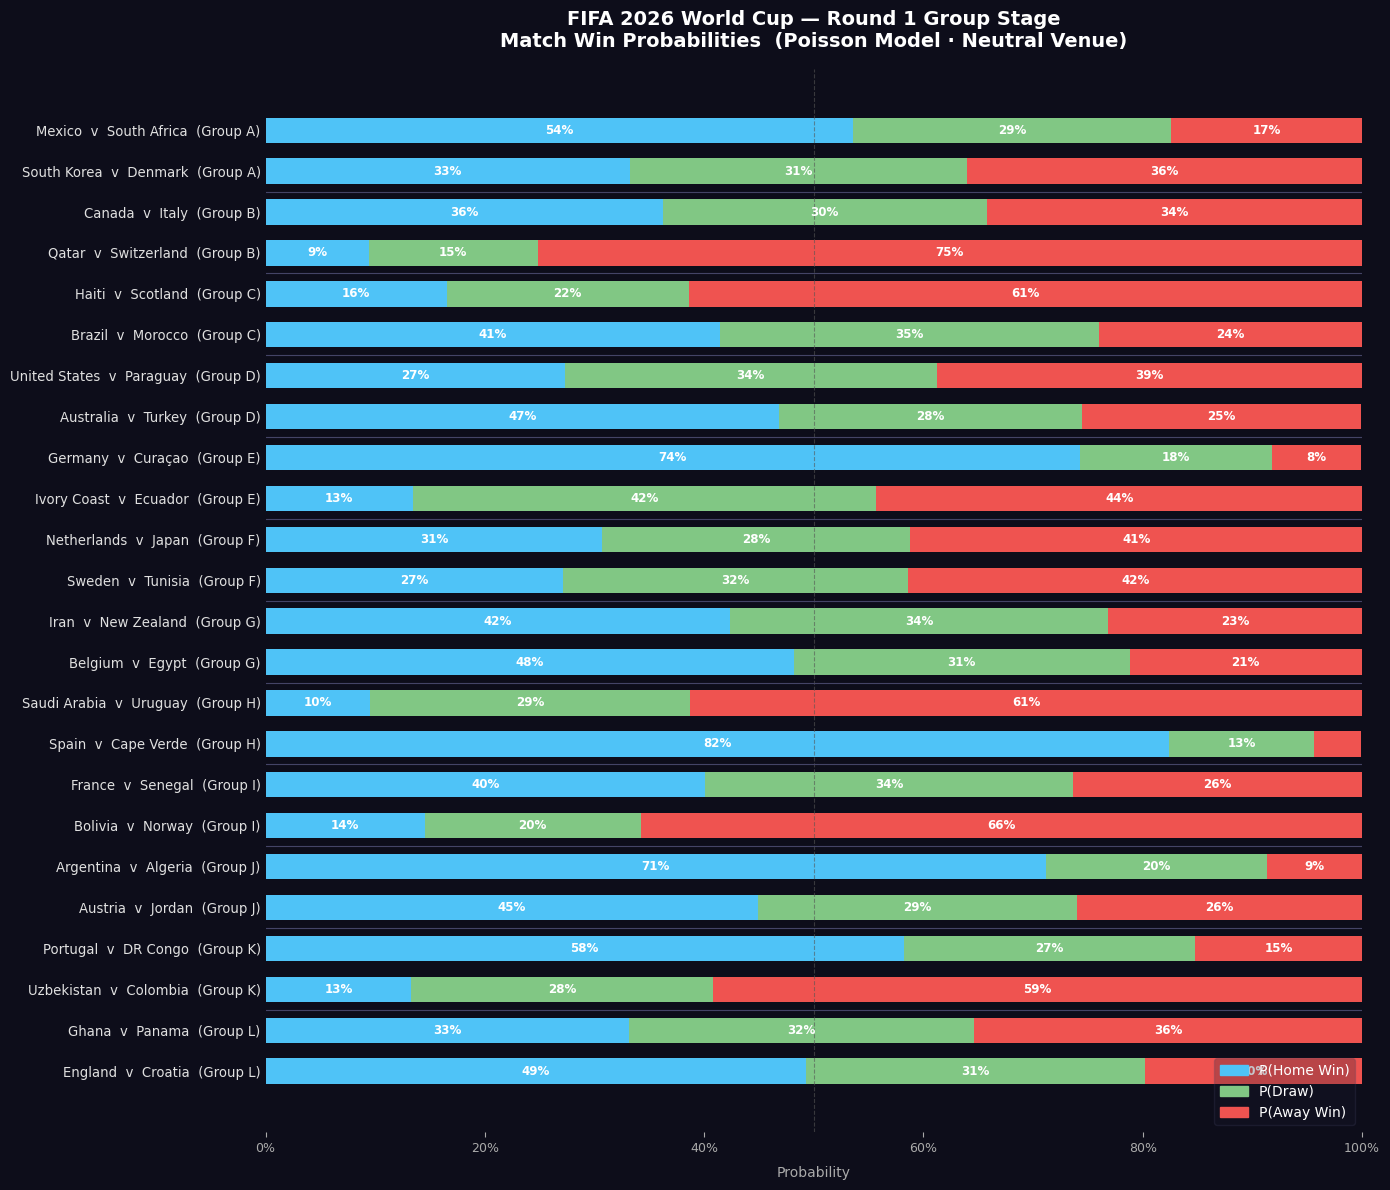

Chart saved → round1_odds_chart.png


In [49]:
# ── ROUND 1 GROUP STAGE — PROBABILITY CHART ──────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')

# Sort by group so matches cluster neatly
df_plot = r1_odds.sort_values(['Group', 'Match']).reset_index(drop=True)
labels  = [f"{r['Home']}  v  {r['Away']}  ({r['Group']})" for _, r in df_plot.iterrows()]
y       = np.arange(len(labels))

ph  = df_plot['P(Home)'].values
pd_ = df_plot['P(Draw)'].values
pa  = df_plot['P(Away)'].values

HOME_CLR = '#4fc3f7'
DRAW_CLR = '#81c784'
AWAY_CLR = '#ef5350'
bar_h    = 0.62

ax.barh(y, ph,        height=bar_h, color=HOME_CLR)
ax.barh(y, pd_,       height=bar_h, left=ph,        color=DRAW_CLR)
ax.barh(y, pa,        height=bar_h, left=ph + pd_,  color=AWAY_CLR)

# Inline percentage labels
for i, (h, d, a) in enumerate(zip(ph, pd_, pa)):
    if h  > 0.08: ax.text(h/2,        i, f'{h:.0%}', va='center', ha='center', fontsize=8.5, color='white', fontweight='bold')
    if d  > 0.07: ax.text(h+d/2,      i, f'{d:.0%}', va='center', ha='center', fontsize=8.5, color='white', fontweight='bold')
    if a  > 0.08: ax.text(h+d+a/2,    i, f'{a:.0%}', va='center', ha='center', fontsize=8.5, color='white', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9.5, color='#e0e0e0')
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis='x', colors='#aaaaaa', labelsize=9)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values(): spine.set_visible(False)
ax.axvline(0.5, color='#555555', linestyle='--', linewidth=0.8, alpha=0.6)

# Group dividers
groups_seq = df_plot['Group'].tolist()
for i in range(1, len(groups_seq)):
    if groups_seq[i] != groups_seq[i-1]:
        ax.axhline(i - 0.5, color='#444466', linewidth=0.8)

ax.legend(
    handles=[
        mpatches.Patch(color=HOME_CLR, label='P(Home Win)'),
        mpatches.Patch(color=DRAW_CLR, label='P(Draw)'),
        mpatches.Patch(color=AWAY_CLR, label='P(Away Win)'),
    ],
    loc='lower right', framealpha=0.25, facecolor='#1a1a2e',
    edgecolor='#444466', labelcolor='white', fontsize=10
)

ax.set_title(
    'FIFA 2026 World Cup — Round 1 Group Stage\nMatch Win Probabilities  (Poisson Model · Neutral Venue)',
    color='white', fontsize=14, fontweight='bold', pad=16
)
ax.set_xlabel('Probability', color='#aaaaaa', fontsize=10, labelpad=8)

plt.tight_layout()
plt.savefig(
    '/Users/ebismac/Desktop/Documents/Betting Odds Generator/round1_odds_chart.png',
    dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor()
)
plt.show()
print("Chart saved → round1_odds_chart.png")
